# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 20     |  |
| :-------------|:-------------|
|Jens Groen | 6353991 |
|Emma Jule Drent| 6507417 |
|Thomas Haak| 6472672 |

| Planning Groep: 20     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Sanity check 1 | 11:00 |
| Mijlpaal 2: Schetsen maken | 11:40 |
| Mijlpaal 1: Criteria opgesteld | 12:30 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:30 |
| Pauze 1| 12:30|
| Pauze 2| 15:15|

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](mooie.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR | Veiligheidssysteem in machines | maximale reactietijd van 5ms, moet lichtintensiteit verschil van 200 lux , moet ongevoelig zijn van omgevingslicht, moet een signaal geven als de sensor niet meer werkt|
|Force sensor | Keukenweegschaal | kan accuraat meten op het interval 1-500 gram, maximale schommeling in waarde van +/- 2 gram, weergeeft enkel het voorwerp dat op de plaat ligt (is zodanig gekalibreerd dat het gewicht van de weegschaal zelf niet meegenomen wordt). |
|Thermistor | Laptop oververhittingsensor | Moet in staat zijn temperaturen tussen 20 en 80 graden te meten, met een schommelling van 3 graden. De correcte temperatuur wordt gegeven in een meting die niet langer dan 3 minuten duurt. Moet signaal geven als de temperatuur boven de 40 graden is. |

Groep 20 heeft gekozen voor de Force sensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Een schets van de opstelling die we gebruiken met daarnaast de schakeling.
 ![Alt](tkening.jpg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? \
    Het gewicht op de sensor
2. Over welk bereik ga je deze variabelen veranderen?\
    50g  tot 300g
3. Wat ga je allemaal meten?\
    Stukken hout met verschillende gewichten
4. Hoeveel metingen ga je doen?\
    50 (10 per gewicht)
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?\
    Ja, want je kan een onbekend gewicht nemen en daarvan het gewicht meten doormiddel van onze gekalibreerde weegschaal (met behulp van een fit) en dit controleren met een echte weegschaal. De onzekerheid geeft ook goed weer welk gewicht de weegschaal nog voldoende kan onderscheiden.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
De schakeling is met een arduino verbonden met een laptop. De krachtsensor rust op een batterij. Hierboven staat een voorwerp die dient als rust, vastgemaakt aan een rulductape voor stabiliteit. Op dit voorwerp kunnen andere voorwerpen worden geplaatst wiens gewicht (gecombineerd met het rustvoorwerp) wordt gemeten.
 ![Alt](plalatje.jpg  "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

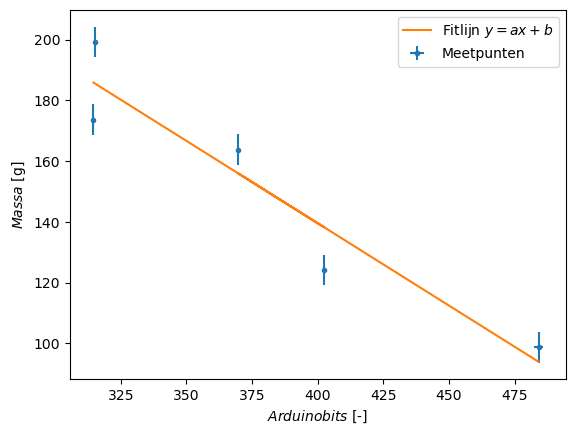

NameError: name 'u_a' is not defined

In [1]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 25.50, klein plankie
# 65.11, 
# 98.66 ijzer ding
# groot plankie, 75.00 g
# ander plankie 65.77 g
# Arrays voor kalibratie

k1 = np.array([486,480,482,476,475,486,485,486,490,495]) #98.66 g
k2 = np.array([371,371,370,370,370,369,369,369,369,369]) #163.77 g
k3 = np.array([402,403,402,402,403,403,403,402,402,402]) #124.16 g
k4 = np.array([317,319,317,318,317,317,314,312,312,310]) #199.27 g
k5 = np.array([316,315,313,316,315,313,314,313,316,315]) #173.66 g

massa = np.array([98.66, 163.77, 124.16, 199.27, 173.66])
bits_arr = np.array([k1, k2, k3, k4, k5])

bits = []
u_bits = []

for i in bits_arr:
    sigma = np.std(i)
    N = len(i)
    u = sigma/np.sqrt(N)
    u_bits.append(u)
    bits.append(np.mean(i))

bits = np.array(bits)

# Fit
def fit(x, a, b):
    return a*x + b

val, cov = curve_fit(fit, bits, massa)
a = val[0]
b = val[1]

plt.figure()
plt.errorbar(bits, massa, xerr=u_bits, yerr=5, fmt='.', label="Meetpunten")
plt.plot(bits, fit(bits, a, b), label= r"Fitlijn $y=ax+b$")
plt.xlabel(r"$Arduino bits$ [-]")
plt.ylabel(r"$Massa$ [g]")
plt.legend()
plt.show()

# onzekerheidsberekening
u = np.sqrt((np.mean(bits) * u_a)**2 + u_b**2 + (a*np.mean(u_bits))**2)

print("De onzekerheid is", u, "g.")

## *Opdracht 7*: Iteratie nodig?

Na het uitvoeren van de metingen met 5 massa's, kwamen we tot de conclusie dat we nmeer meetpunten nodig hebben om een nauwkeurige fitlijn te vormen. Er zijn meerdere metingen gedaan rondom de punten die sterk afweken van de huidige fit

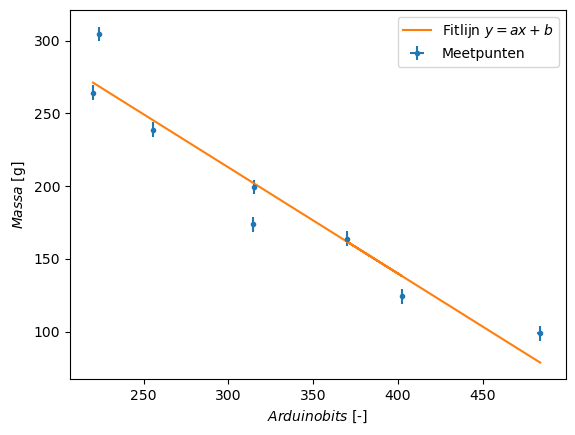

De onzekerheid is 41.2509744806827 g.


In [ ]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 25.50, klein plankie
# 65.11, 
# 98.66 ijzer ding
# groot plankie, 75.00 g
# ander plankie 65.77 g
# Arrays voor kalibratie

k1 = np.array([486,480,482,476,475,486,485,486,490,495]) #98.66 g
k2 = np.array([371,371,370,370,370,369,369,369,369,369]) #163.77 g
k3 = np.array([402,403,402,402,403,403,403,402,402,402]) #124.16 g
k4 = np.array([317,319,317,318,317,317,314,312,312,310]) #199.27 g
k5 = np.array([316,315,313,316,315,313,314,313,316,315]) #173.66 g
k6 = np.array([256,255,255,256,255,256,256,256,256,255]) #238.77 g
k7 = np.array([224,224,224,224,224,223,224,222,224,224]) #304.54 g
k8 = np.array([220,220,222,219,221,219,219,219,220,221]) #264.27 g

massa = np.array([98.66, 163.77, 124.16, 199.27, 173.66, 238.77,304.54,264.27])
bits_arr = np.array([k1, k2, k3, k4, k5, k6, k7, k8])

bits = []
u_bits = []

for i in bits_arr:
    sigma = np.std(i)
    N = len(i)
    u = sigma/np.sqrt(N)
    u_bits.append(u)
    bits.append(np.mean(i))

bits = np.array(bits)

# Fit
def fit(x, a, b):
    return a*x + b

val, cov = curve_fit(fit, bits, massa)
a, b = val
u_a = np.sqrt(cov[0,0])
u_b = np.sqrt(cov[1,1])

plt.figure()
plt.errorbar(bits, massa, xerr=u_bits, yerr=5, fmt='.', label="Meetpunten")
plt.plot(bits, fit(bits, a, b), label= r"Fitlijn $y=ax+b$")
plt.xlabel(r"$Arduino bits$ [-]")
plt.ylabel(r"$Massa$ [g]")
plt.legend()
plt.show()

# onzekerheidsberekening
u = np.sqrt((np.mean(bits) * u_a)**2 + u_b**2 + (a*np.mean(u_bits))**2)

print("De onzekerheid is", u, "g.")

Hierna is geen iteratie meer nodig gebleken, omdat de fit voldoende is verbeterd.

Hier kan je de bits waarde invullen en geeft de fit je het bijpassende gewicht

In [ ]:
waarde = 200 # vul hier de bits in die op de weegschaal staan
print(fit(waarde, a, b))

247.99884986287316


## *Opdracht 8*: Conclusie, leerdoel

Op basis van onze metingen kunnen we concluderen dat deze sensor binnen een onzekerheid van 41.3 gram gebruikt kan worden als weegschaal van objecten met een massa tussen de 98.66 en de 304.54 gram. De weegschaal kan dus alleen onderscheid maken tussen voorwerpen met sterk verschillende massa's.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

Hier zie je de schakeling die werkt met een 10 kilo Ohm weerstand en een krachtsensor geplaatst zodat het werkt als een spanningsdeler. Dit is aangesloten op een arduino die is verbonden met een laptop.
 ![Alt](circuit.jpg  "meetopstelling student")

#### *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
De schakeling is met een arduino verbonden met een laptop. De krachtsensor rust op een batterij. Hierboven staat een voorwerp die dient als rust, vastgemaakt aan een rulductape voor stabiliteit. Op dit voorwerp kunnen andere voorwerpen worden geplaatst wiens gewicht (gecombineerd met het rustvoorwerp) wordt gemeten.
 ![Alt](plalatje.jpg  "meetopstelling student")

#### *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Een schets van de opstelling die we gebruiken met daarnaast de schakeling.
 ![Alt](tkening.jpg "schets student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

#### *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR | Veiligheidssysteem in machines | maximale reactietijd van 5ms, moet lichtintensiteit verschil van 200 lux , moet een signaal geven als de sensor niet meer werkt|
|Force sensor | Keukenweegschaal | kan accuraat meten op het interval 1-500 gram, maximale schommeling in waarde van +/- 2 gram, weergeeft enkel het voorwerp dat op de plaat ligt (is zodanig gekalibreerd dat het gewicht van de weegschaal zelf niet meegenomen wordt). |
|Thermistor | Laptop oververhittingsensor | Moet in staat zijn temperaturen tussen 20 en 80 graden te meten, met een schommelling van 3 graden. De correcte temperatuur wordt gegeven in een meting die niet langer dan 3 minuten duurt. Moet signaal geven als de temperatuur boven de 40 graden is. |

Groep 20 heeft gekozen voor de Force sensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

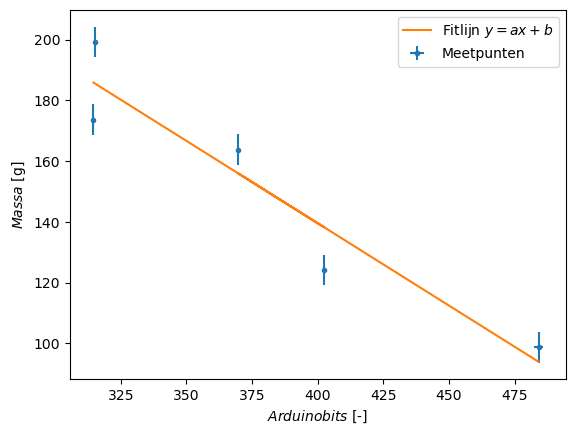

De onzekerheid is 44.71424549254058 g.


In [ ]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 25.50, klein plankie
# 65.11, 
# 98.66 ijzer ding
# groot plankie, 75.00 g
# ander plankie 65.77 g
# Arrays voor kalibratie

k1 = np.array([486,480,482,476,475,486,485,486,490,495]) #98.66 g
k2 = np.array([371,371,370,370,370,369,369,369,369,369]) #163.77 g
k3 = np.array([402,403,402,402,403,403,403,402,402,402]) #124.16 g
k4 = np.array([317,319,317,318,317,317,314,312,312,310]) #199.27 g
k5 = np.array([316,315,313,316,315,313,314,313,316,315]) #173.66 g

massa = np.array([98.66, 163.77, 124.16, 199.27, 173.66])
bits_arr = np.array([k1, k2, k3, k4, k5])

bits = []
u_bits = []

for i in bits_arr:
    sigma = np.std(i)
    N = len(i)
    u = sigma/np.sqrt(N)
    u_bits.append(u)
    bits.append(np.mean(i))

bits = np.array(bits)

# Fit
def fit(x, a, b):
    return a*x + b

val, cov = curve_fit(fit, bits, massa)
a = val[0]
b = val[1]

plt.figure()
plt.errorbar(bits, massa, xerr=u_bits, yerr=5, fmt='.', label="Meetpunten")
plt.plot(bits, fit(bits, a, b), label= r"Fitlijn $y=ax+b$")
plt.xlabel(r"$Arduino bits$ [-]")
plt.ylabel(r"$Massa$ [g]")
plt.legend()
plt.show()

# onzekerheidsberekeningen
u = np.sqrt((np.mean(bits) * u_a)**2 + u_b**2 + (a*np.mean(u_bits))**2)

print("De onzekerheid is", u, "g.")

#### *Opdracht 8*: Conclusie, leerdoel

Op basis van onze metingen kunnen we concluderen dat deze sensor binnen een onzekerheid van 41.3 gram gebruikt kan worden als weegschaal van objecten met een massa tussen de 98.66 en de 304.54 gram. De weegschaal kan dus alleen onderscheid maken tussen voorwerpen met sterk verschillende massa's.